# 팀원 2 — 가맹점·창업비용·매출 담당

**데이터 출처:** 공정거래위원회 가맹사업 정보제공시스템 (공공데이터포털 API)  
**수집 기간:** 2022~2024년 (가맹사업기준년도 기준이므로, 실제 회계연도는 1년 전)  
**분석 대상 업종:** 한식음식점, 커피-음료, 양식음식점, 호프-간이주점, 편의점, 일식음식점, 중식음식점

---
## 1. 데이터 수집 과정

### 1-1. 사용 API 목록

| API 서비스명 | 엔드포인트 | 용도 |
|---|---|---|
| FftcBrandRlsInfo2_Service | /getBrandinfo | 업종별 브랜드 목록 및 brandMnno 수집 |
| FftcBrandFrcsDropInfo2_Service | /getbrandFrcsDmsstus | 연도별 가맹점 수 (지역별) |
| FftcBrandFrcsUnitAvrSalInfo2_Service | /getbrandFrcsBzmnAvrgsls | 브랜드별 가맹점 연평균 매출 |
| FftcBrandFntnStatsService | /getBrandFntnStats | 브랜드별 창업비용 (가맹금+교육비+보증금+기타) |
| FftcBrandFrcsIntInfo2_Service | /getbrandFrcsBzmnIntrrctinfo | 브랜드별 인테리어 비용 |

### 1-2. 수집 시 주요 처리 사항

**연도 밀림 보정:**  
`jngBizCrtraYr`(가맹사업기준년도)와 `acntgYr`(회계년도)가 1년 차이남.  
예) `jngBizCrtraYr=2023` → `acntgYr=2022` 데이터  
→ 2022년 데이터를 얻으려면 `jngBizCrtraYr=2023`으로 호출

**매출 범위값 처리:**  
`fyerAvrgSlsAmtScopeVal`이 `'460000~520000'` 형태로 제공됨.  
→ 중간값 `(460000+520000)/2 = 490000` 사용. 단위: 천원

**창업비 매핑 방식:**  
`getBrandFntnStats`는 `brandMnno` 파라미터 미지원 → 연도별 전체 수집 후 `brandNm`으로 매핑

**창업비 합계 정의:**  
`창업비 합계 = 가맹금 + 교육비 + 보증금 + 기타비용 + 인테리어비용`

### 1-3. 브랜드 선정 기준
- 3개년(2022~2024) 중 하나라도 가맹점 수 10개(일식/중식은 5개) 이상
- 가맹점 수, 평균매출 각각 최소 2개년 데이터 존재

### 1-4. 이상치 제거
- **방식:** 업종별 상하위 5% 절사 (trimmed mean)
- **적용 컬럼:** 평균매출(3개년), 인테리어비용, 창업비 합계
- **미적용 컬럼:** 가맹점 수 (브랜드 규모 자체를 나타내므로 제외)
- **미적용 업종:** 편의점 (데이터 자체의 양이 적으므로 제외)
- **결과:** 910개 → 676개 (234개 제거)

### 1-5. 업종 매핑 테이블

| 공정위 indutyMlsfcNm | 우리 팀 biz |
|---|---|
| 한식, 치킨 | 한식음식점 |
| 커피, 음료(커피 외) | 커피-음료 |
| 서양식, 피자 | 양식음식점 |
| 주점 | 호프-간이주점 |
| 편의점 | 편의점 |
| 일식 | 일식음식점 |
| 중식 | 중식음식점 |
- 반찬가게, 컴퓨터및주변장치판매 → 매핑할 세부 업종 없음
- 의약품, 일반의류, 슈퍼마켓은 가져올 프랜차이즈 브랜드 데이터의 개수가 유의미하지 못함
- 위의 업종들보다 좀 더 창업 시 접근이 쉬운 일식, 중식 업종을 추가함

---
## 2. 변수 정의

### brand_data.csv (데이터 수집 csv 파일)

| 컬럼명 | 설명 | 단위 | 출처 |
|---|---|---|---|
| 브랜드명 | 프랜차이즈 브랜드명 | - | getBrandinfo |
| 브랜드관리번호 | 공정위 브랜드 고유 ID | - | getBrandinfo |
| biz | 우리 팀 업종 분류 | - | 매핑 |
| 2022_가맹점수 | 2022년 전국 가맹점 수 | 개 | getbrandFrcsDmsstus |
| 2023_가맹점수 | 2023년 전국 가맹점 수 | 개 | getbrandFrcsDmsstus |
| 2024_가맹점수 | 2024년 전국 가맹점 수 | 개 | getbrandFrcsDmsstus |
| 2022_평균매출(천원) | 2022년 가맹점 연평균 매출 | 천원 | getbrandFrcsBzmnAvrgsls |
| 2023_평균매출(천원) | 2023년 가맹점 연평균 매출 | 천원 | getbrandFrcsBzmnAvrgsls |
| 2024_평균매출(천원) | 2024년 가맹점 연평균 매출 | 천원 | getbrandFrcsBzmnAvrgsls |
| 평균매출(천원) | 3개년 평균매출 평균 | 천원 | 계산 |
| 인테리어비용(천원) | 가맹점 평균 인테리어 비용 | 천원 | getbrandFrcsBzmnIntrrctinfo |
| 창업비 합계(천원) | 가맹금+교육비+보증금+기타+인테리어 | 천원 | getBrandFntnStats + 인테리어 |

### biz_summary.csv (최종 산출물)

| 변수명 | 설명 | 단위 | 통계값 |
|---|---|---|---|
| avg_initial_cost | 업종 평균 창업비 합계 | 천원 | mean/median/q25/q75 |
| avg_interior_cost | 업종 평균 인테리어 비용 | 천원 | mean/median/q25/q75 |
| avg_franchise_sales | 업종 가맹점 연평균 매출 | 천원 | mean/median/q25/q75 |
| avg_franchise_lifespan | 업종 가맹점 평균 영업기간 | 개월 | 단일값 (공정위 집계) |
| franchise_count_growth_yoy | 가맹점 수 YoY 평균 증가율 | % | mean/median/q25/q75 |

#### 산출 방식:

- `avg_initial_cost`: 창업비 합계(천원) 컬럼 기준.
    - 창업비 합계 = 공정위 getBrandFntnStats API의 가맹금+교육비+보증금+기타비용+인테리어비용. 업종 내 브랜드별 값의 통계 산출.
- `avg_interior_cost`: 인테리어비용(천원) 컬럼 기준.
    - getbrandFrcsBzmnIntrrctinfo API의 intrrAmtScopeVal 범위값 중간값 사용 (예: 15000~18000 → 16500).
- `avg_franchise_sales`: 브랜드별로 2022~2024 연평균 매출의 평균을 먼저 계산 후 업종 통계 산출.
    - getbrandFrcsBzmnAvrgsls API의 areaNm='전체' 행 fyerAvrgSlsAmtScopeVal 중간값 사용. 데이터 있는 연도만으로 평균.
- `avg_franchise_lifespan`: 공정위 가맹사업현황 통계 2022~2024년 업종별 평균 영업기간(일) 3개년 평균을 30으로 나눠 개월로 변환.
    - 공정위 업종 두 개가 하나의 biz로 매핑되는 경우(한식+치킨→한식음식점 등) 전체 평균 사용.
- `franchise_count_growth_yoy`: 브랜드별 (2023-2022)/2022 + (2024-2023)/2023) / 2 계산 후 업종 통계 산출.
    - 데이터 있는 구간만 계산에 포함.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

import matplotlib
import platform
if platform.system() == 'Windows':
    matplotlib.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':
    matplotlib.rc('font', family='AppleGothic')
else:
    matplotlib.rc('font', family='NanumGothic')
matplotlib.rcParams['axes.unicode_minus'] = False

colors = plt.cm.tab10.colors

df = pd.read_csv('brand_data.csv')
summary = pd.read_csv('biz_summary.csv')

print(f'브랜드 데이터: {len(df)}개 브랜드, {len(df.columns)}개 컬럼')
print(f'업종 요약 데이터: {len(summary)}개 업종')
print()
print('업종별 브랜드 수:')
print(df['biz'].value_counts())

브랜드 데이터: 676개 브랜드, 12개 컬럼
업종 요약 데이터: 7개 업종

업종별 브랜드 수:
biz
한식음식점      234
일식음식점      130
호프-간이주점     94
커피-음료       76
중식음식점       76
양식음식점       57
편의점          9
Name: count, dtype: int64


---
## 3. brand_data.csv 시각화

### 3-1. 업종별 브랜드 수

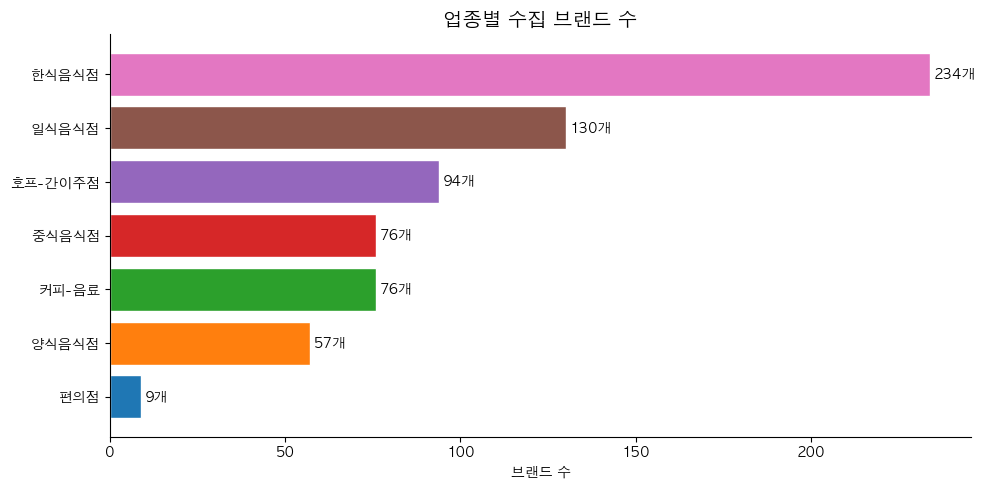

In [14]:
biz_counts = df['biz'].value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(biz_counts.index, biz_counts.values,
               color=[colors[i] for i in range(len(biz_counts))], edgecolor='white')
for bar, val in zip(bars, biz_counts.values):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{val}개', va='center', fontsize=10)
ax.set_xlabel('브랜드 수')
ax.set_title('업종별 수집 브랜드 수', fontsize=14, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

- 편의점의 경우 실제 수집할만 한 프랜차이즈 브랜드 종류가 제한적

### 3-2. 업종별 가맹점 수 추이 (편의점 분리)

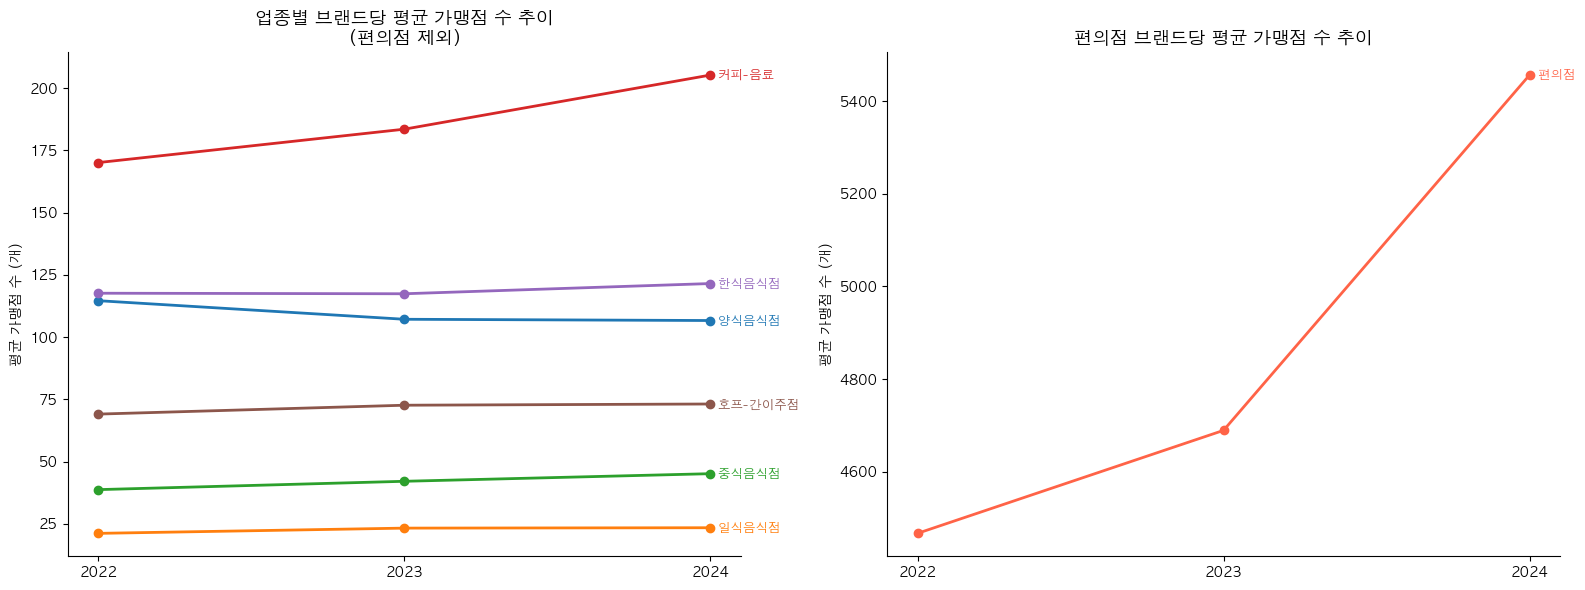

In [16]:
frcs_cols = ['2022_가맹점수', '2023_가맹점수', '2024_가맹점수']
frcs_trend = df.groupby('biz')[frcs_cols].mean()
years = ['2022', '2023', '2024']
biz_others = [b for b in frcs_trend.index if b != '편의점']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
for i, biz in enumerate(biz_others):
    vals = frcs_trend.loc[biz].values
    ax.plot(years, vals, marker='o', label=biz, color=colors[i], linewidth=2)
    ax.text(years[-1], vals[-1], f'  {biz}', va='center', fontsize=9, color=colors[i])
ax.set_ylabel('평균 가맹점 수 (개)')
ax.set_title('업종별 브랜드당 평균 가맹점 수 추이\n(편의점 제외)', fontsize=13, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax = axes[1]
vals = frcs_trend.loc['편의점'].values
ax.plot(years, vals, marker='o', color='tomato', linewidth=2)
ax.text(years[-1], vals[-1], '  편의점', va='center', fontsize=9, color='tomato')
ax.set_ylabel('평균 가맹점 수 (개)')
ax.set_title('편의점 브랜드당 평균 가맹점 수 추이', fontsize=13, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

- 타 업종에 비해 커피-음료, 편의점의 가맹점 수 증가율이 가파름

### 3-3. 업종별 평균매출 분포 (박스플롯)

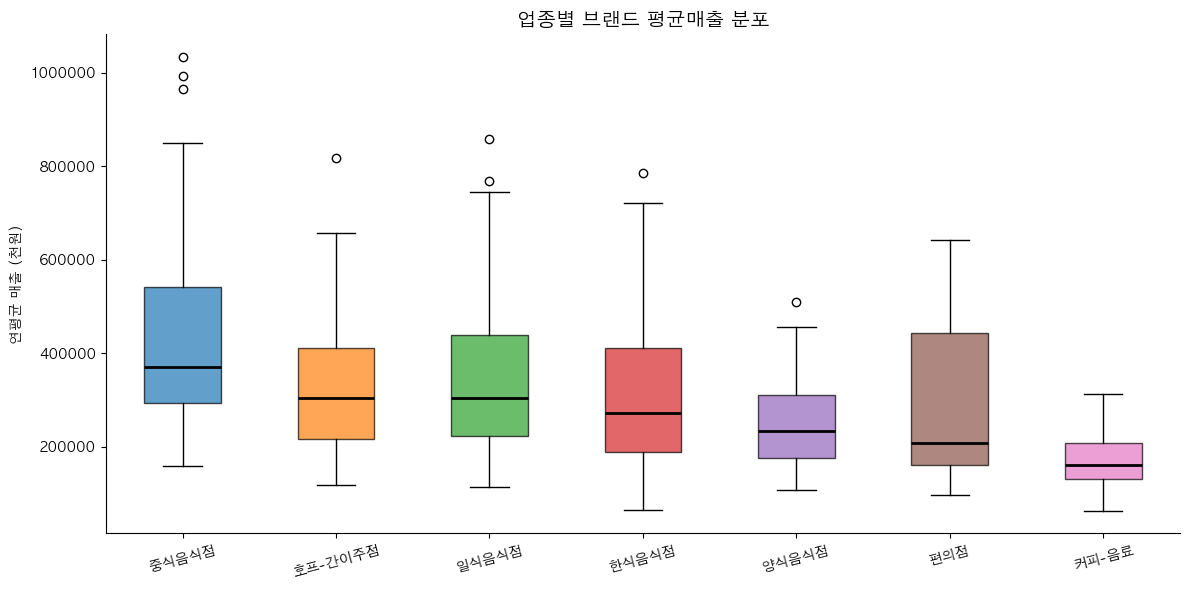

In [18]:
biz_order = df.groupby('biz')['평균매출(천원)'].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(12, 6))
data_by_biz = [df[df['biz'] == biz]['평균매출(천원)'].dropna().values for biz in biz_order]

bp = ax.boxplot(data_by_biz, labels=biz_order, patch_artist=True,
                medianprops=dict(color='black', linewidth=2))
for i, patch in enumerate(bp['boxes']):
    patch.set_facecolor(colors[i % len(colors)])
    patch.set_alpha(0.7)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x)}'))
ax.set_ylabel('연평균 매출 (천원)')
ax.set_title('업종별 브랜드 평균매출 분포', fontsize=14, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

---
## 4. biz_summary.csv 시각화

### 4-1. 창업비 vs 평균매출 산점도

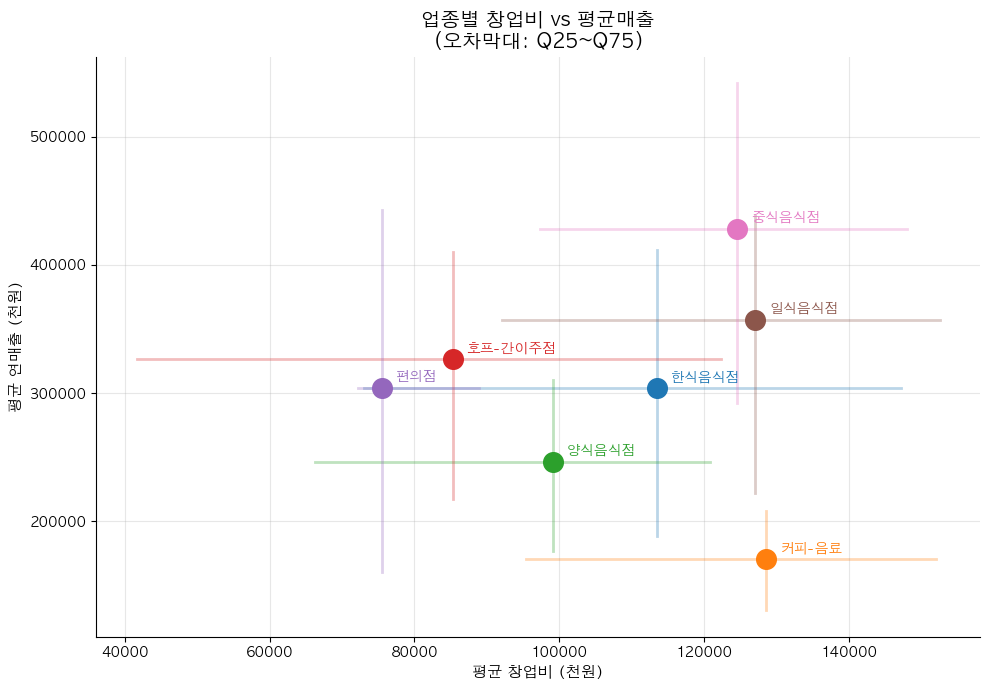

In [26]:
fig, ax = plt.subplots(figsize=(10, 7))

for i, row in summary.iterrows():
    x = row['avg_initial_cost_mean']
    y = row['avg_franchise_sales_mean']
    ax.scatter(x, y, s=200, color=colors[i], zorder=5)
    ax.annotate(row['biz'], (x, y),
                textcoords='offset points', xytext=(10, 5),
                fontsize=10, color=colors[i], fontweight='bold')
    ax.plot([row['avg_initial_cost_q25'], row['avg_initial_cost_q75']],
            [y, y], color=colors[i], alpha=0.3, linewidth=2)
    ax.plot([x, x],
            [row['avg_franchise_sales_q25'], row['avg_franchise_sales_q75']],
            color=colors[i], alpha=0.3, linewidth=2)

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x)}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x)}'))
ax.set_xlabel('평균 창업비 (천원)', fontsize=11)
ax.set_ylabel('평균 연매출 (천원)', fontsize=11)
ax.set_title('업종별 창업비 vs 평균매출\n(오차막대: Q25~Q75)', fontsize=14, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 4-2. 업종별 YoY 성장률 중앙값

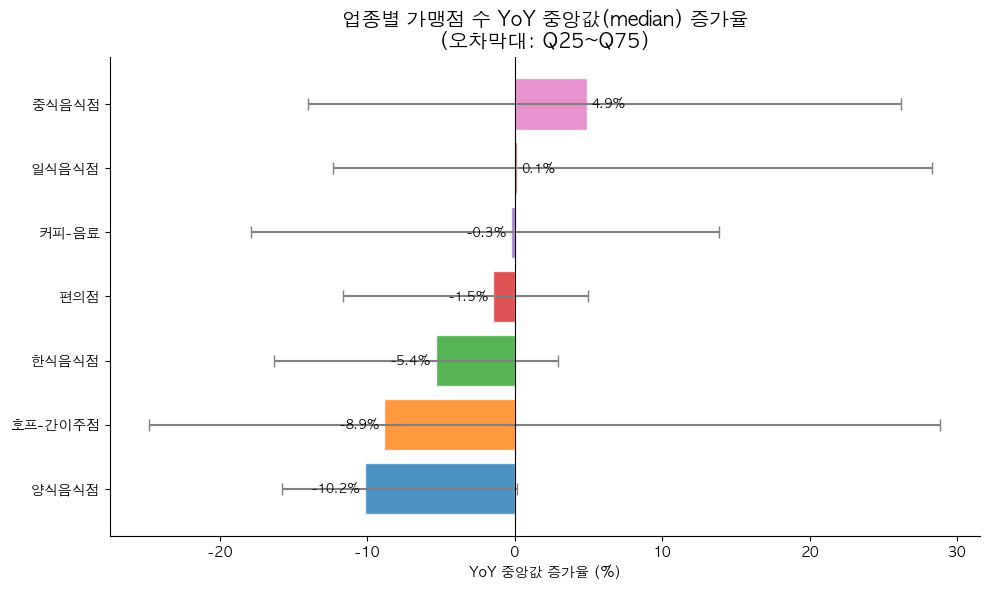

In [35]:
summary_sorted = summary.sort_values('franchise_count_growth_yoy_median', ascending=True)
fig, ax = plt.subplots(figsize=(10, 6))
y_pos = range(len(summary_sorted))
bar_colors = [colors[i] for i in range(len(summary_sorted))]
bars = ax.barh(y_pos, summary_sorted['franchise_count_growth_yoy_median'],
               color=bar_colors, alpha=0.8, edgecolor='white')
xerr_low  = (summary_sorted['franchise_count_growth_yoy_median'] - summary_sorted['franchise_count_growth_yoy_q25']).abs()
xerr_high = (summary_sorted['franchise_count_growth_yoy_q75'] - summary_sorted['franchise_count_growth_yoy_median']).abs()
ax.errorbar(summary_sorted['franchise_count_growth_yoy_median'], y_pos,
            xerr=[xerr_low, xerr_high], fmt='none', color='gray', capsize=4)
for bar, val in zip(bars, summary_sorted['franchise_count_growth_yoy_median']):
    ax.text(val + (0.3 if val >= 0 else -0.3), bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', ha='left' if val >= 0 else 'right', fontsize=9)
ax.set_yticks(y_pos)
ax.set_yticklabels(summary_sorted['biz'])
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('YoY 중앙값 증가율 (%)')
ax.set_title('업종별 가맹점 수 YoY 중앙값(median) 증가율\n(오차막대: Q25~Q75)', fontsize=14, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

### 4-3. 업종별 평균 영업기간

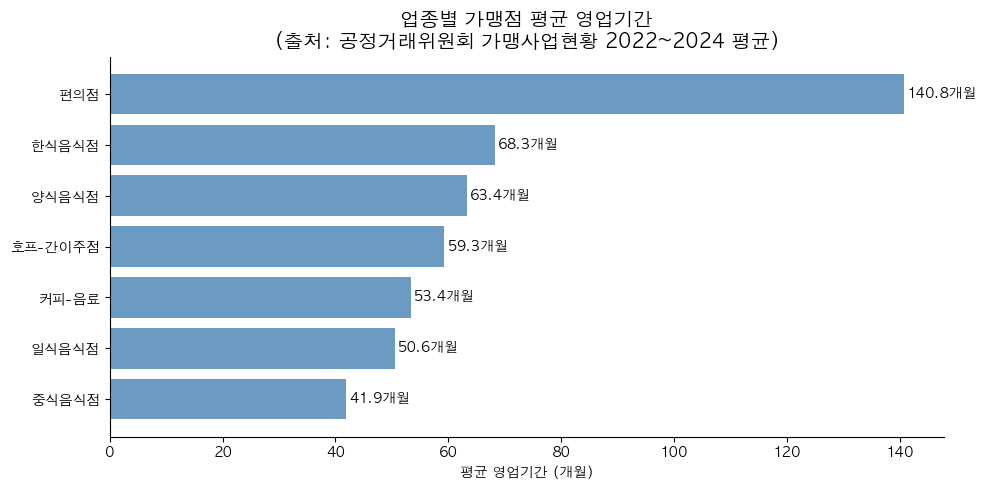

In [38]:
summary_life = summary.sort_values('avg_franchise_lifespan', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(summary_life['biz'], summary_life['avg_franchise_lifespan'],
               color='steelblue', alpha=0.8)
for bar, val in zip(bars, summary_life['avg_franchise_lifespan']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}개월', va='center', fontsize=10)

ax.set_xlabel('평균 영업기간 (개월)')
ax.set_title('업종별 가맹점 평균 영업기간\n(출처: 공정거래위원회 가맹사업현황 2022~2024 평균)', fontsize=14, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

---
## 5. 데이터 품질 확인

In [40]:
print('=== 결측치 현황 (brand_data.csv) ===')
null_pct = (df.isnull().sum() / len(df) * 100).round(1)
print(null_pct[null_pct > 0].to_string())
print()

print('=== 업종별 주요 통계 ===')
stats_df = df.groupby('biz').agg(
    브랜드수=('브랜드명', 'count'),
    평균매출_평균=('평균매출(천원)', 'mean'),
    창업비_평균=('창업비 합계(천원)', 'mean'),
    인테리어_평균=('인테리어비용(천원)', 'mean'),
).round(0)
print(stats_df.to_string())

=== 결측치 현황 (brand_data.csv) ===
브랜드관리번호          1.0
2022_가맹점수        4.9
2023_가맹점수        2.7
2024_가맹점수        7.1
2022_평균매출(천원)    9.6
2023_평균매출(천원)    1.9
2024_평균매출(천원)    8.1
인테리어비용(천원)       0.7

=== 업종별 주요 통계 ===
         브랜드수   평균매출_평균    창업비_평균  인테리어_평균
biz                                       
양식음식점      57  246487.0   99162.0  25920.0
일식음식점     130  356985.0  127056.0  38035.0
중식음식점      76  428033.0  124508.0  38395.0
커피-음료      76  170555.0  128582.0  34388.0
편의점         9  303869.0   75577.0  16644.0
한식음식점     234  303727.0  113532.0  36159.0
호프-간이주점    94  326303.0   85277.0  47234.0


---
## 6. 검증 체크리스트
### 우리 10개 업종 모두에 대해 비용 데이터가 있는가? (없으면 그 업종은 NaN, 전체 평균으로 대체)
- 반찬가게, 컴퓨터및주변장치판매 업종은 매핑할 업종이 존재하지 않음
- 의약품, 일반의류, 슈퍼마켓은 데이터의 양과 질(적은 가맹점 수, 일정하지 않은 비용 등)의 상태가 좋지 못함

### 가맹비 + 인테리어 비용 합이 업종별로 5천만 ~ 5억 범위인가?

- 평균 비용이 7500만원 ~ 1억 5천 사이

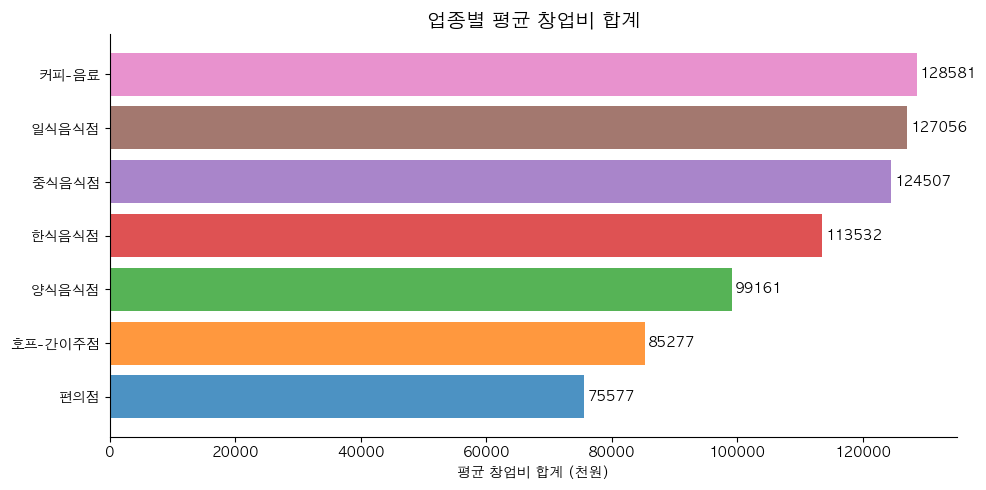

In [42]:
cost_avg = df.groupby('biz')['창업비 합계(천원)'].mean().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(cost_avg.index, cost_avg.values,
               color=[colors[i] for i in range(len(cost_avg))], alpha=0.8)
for bar, val in zip(bars, cost_avg.values):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
            f'{int(val)}', va='center', fontsize=10)

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x)}'))
ax.set_xlabel('평균 창업비 합계 (천원)')
ax.set_title('업종별 평균 창업비 합계', fontsize=14, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

### 평균 영업기간이 12개월 이상인가? (1년 미만은 데이터 이상)

- 모든 업종 12개월 이상

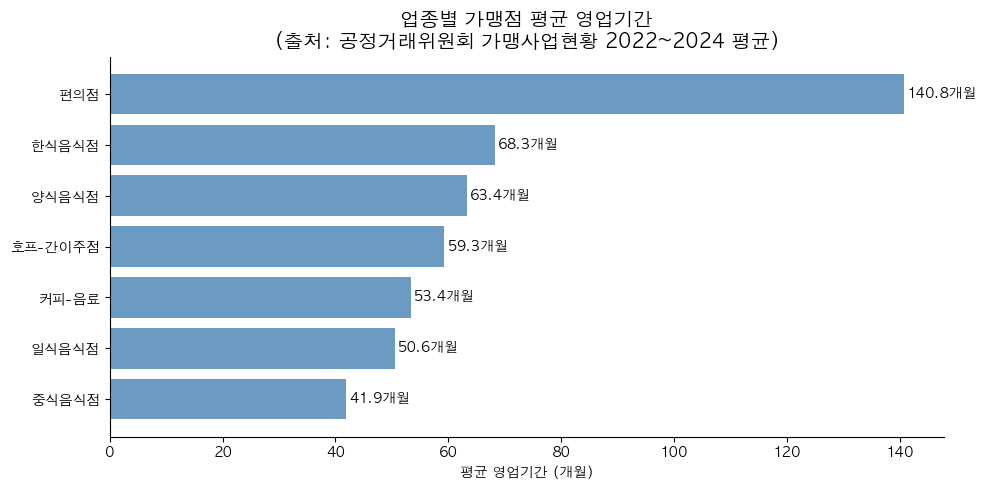

In [44]:
summary_life = summary.sort_values('avg_franchise_lifespan', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(summary_life['biz'], summary_life['avg_franchise_lifespan'],
               color='steelblue', alpha=0.8)
for bar, val in zip(bars, summary_life['avg_franchise_lifespan']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}개월', va='center', fontsize=10)

ax.set_xlabel('평균 영업기간 (개월)')
ax.set_title('업종별 가맹점 평균 영업기간\n(출처: 공정거래위원회 가맹사업현황 2022~2024 평균)', fontsize=14, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

---
## 7. 최종 산출물
- biz_summary.csv
    - 행: 업종, 열: 변수
- biz_summary_T.csv (행, 열 transpose된 csv 파일)
    - 행: 변수, 열: 업종
    - 우리 팀의 franchise.csv는 업종을 컬럼으로 두기에 transpose된 csv 이용해야 함